### Carga y Preprocesamiento del Dataset
Cargamos el dataset **MNIST** (dígitos). A diferencia de la GAN simple, aquí prepararemos los datos para una red convolucional, aunque el escalado inicial es similar.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# extra code – loads, scales, and splits the fashion MNIST dataset
fashion_mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
def plot_multiple_images(images, n_cols=None):
    images = np.array(images)

    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1

    # Ahora que es un array de Numpy, .squeeze() funcionará perfectamente
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)

    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")

In [4]:
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [5]:
def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
    generator, discriminator = gan.layers
    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1}/{n_epochs}")  # extra code
        for X_batch in dataset:
            # phase 1 - training the discriminator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            generated_images = generator(noise)
            X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.trainable = True
            discriminator.train_on_batch(X_fake_and_real, y1)
            discriminator.trainable = False
            # phase 2 - training the generator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            y2 = tf.constant([[1.]] * batch_size)
            gan.train_on_batch(noise, y2)
        # extra code — plot images during training
        plot_multiple_images(generated_images.numpy(), 8)
        plt.show()

    return generated_images

### Arquitectura DCGAN (Deep Convolutional GAN)
Implementamos la arquitectura propuesta por **Radford et al.**, adaptada por A. Géron.
* **Generador:** Usa capas `Conv2DTranspose` (convoluciones transpuestas) para hacer "upsampling", pasando de un vector de ruido pequeño a una imagen de 28x28. Usa activación `tanh` en la salida.
* **Discriminador:** Usa capas `Conv2D` estándar con `LeakyReLU` y `Dropout` para reducir la imagen a una probabilidad binaria.

In [6]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

def build_dcgan(codings_size):
    # Generador
    generator = tf.keras.Sequential([
        tf.keras.layers.Input(shape=[codings_size]),
        tf.keras.layers.Dense(7 * 7 * 128),
        tf.keras.layers.Reshape([7, 7, 128]),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding="same", activation="tanh"),
    ])

    # Discriminador
    discriminator = tf.keras.Sequential([
        tf.keras.layers.Input(shape=[28, 28, 1]),
        tf.keras.layers.Conv2D(64, kernel_size=5, strides=2, padding="same",
                            activation=tf.keras.layers.LeakyReLU(0.2)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Conv2D(128, kernel_size=5, strides=2, padding="same",
                            activation=tf.keras.layers.LeakyReLU(0.2)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    gan = tf.keras.Sequential([generator, discriminator])

    # Compilamos
    discriminator.compile(loss="binary_crossentropy", optimizer="rmsprop")
    discriminator.trainable = False
    gan.compile(loss="binary_crossentropy", optimizer="rmsprop")

    return gan, generator, discriminator

### Ajuste de Dimensiones y Escalado
Las redes convolucionales esperan tensores 4D `(batch, altura, anchura, canales)`.
* Hacemos un **reshape** para añadir el canal de color (escala de grises = 1): `(28, 28, 1)`.
* Re-escalamos los valores al rango **[-1, 1]** (en lugar de [0, 1]) porque el generador usa `tanh` como función de activación final.

In [7]:
# PREPARACIÓN DE DATOS
X_train_dcgan = X_train.reshape(-1, 28, 28, 1) * 2. - 1.
batch_size = 32
dataset = tf.data.Dataset.from_tensor_slices(X_train_dcgan)
dataset = dataset.shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

### Experimento con Tamaños de Vector Latente
Ejecutamos el entrenamiento iterando sobre los tamaños **10, 50 y 100**. Como las DCGAN son más complejas, cada época tardará más que en la versión simple, pero los resultados suelen ser superiores en definición.

In [8]:
# BUCLE DE EXPERIMENTACIÓN
sizes_to_test = [10, 50, 100]
final_blocks_conv = {}

for size in sizes_to_test:
    print(f"\nEntrenando DCGAN con vector de entrada: {size}")
    gan, generator, _ = build_dcgan(size)
    last_block = train_gan(gan, dataset, batch_size, size, n_epochs=10) # Ajusta n_epochs (DCGAN tarda más)
    final_blocks_conv[size] = last_block

Output hidden; open in https://colab.research.google.com to view.


COMPARATIVA FINAL
Tamaño Input: 10


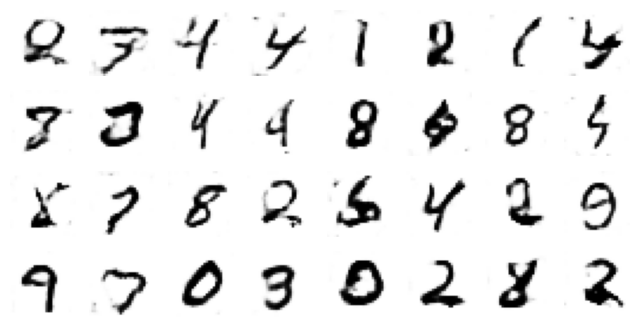

Tamaño Input: 50


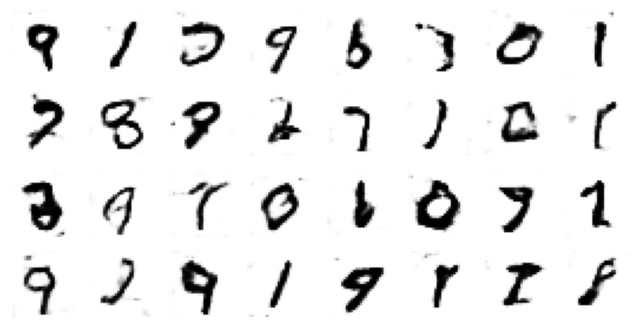

Tamaño Input: 100


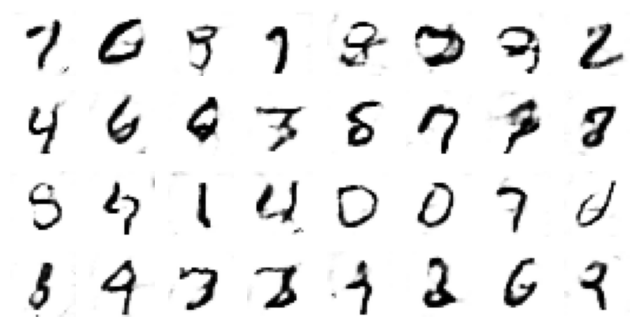

In [13]:
print("\nCOMPARATIVA FINAL")
for size in sizes_to_test:
    print(f"Tamaño Input: {size}")
    plot_multiple_images(final_blocks_conv[size], n_cols=8)
    plt.show()

### Observaciones y Conclusiones (DCGAN)

Tras probar la arquitectura Convolucional (DCGAN) con diferentes tamaños de entrada, se observa:

1.  **Calidad General:**
    * Comparado con la GAN simple del ejercicio anterior, la **DCGAN produce imágenes mucho más nítidas y realistas** en todos los casos. Los trazos son continuos y los fondos más limpios.

2.  **Influencia del Tamaño del Vector (10 vs 50 vs 100):**
    * **Tamaño 10:** A diferencia de la GAN simple, la DCGAN es capaz de aprovechar mejor incluso un vector pequeño. Sin embargo, se nota una **menor diversidad** (muchos 1 o 7 parecidos) y cierta rigidez en los estilos.
    * **Tamaño 50:** Suele ofrecer el mejor balance. La red tiene suficiente capacidad para generar variantes complejas de los números (diferentes inclinaciones y grosores) sin perder definición.
    * **Tamaño 100:** No aporta una mejora visual drástica respecto a 50. Dado que la DCGAN tiene muchos más parámetros, aumentar la entrada a 100 no "desborda" la red, pero tampoco es estrictamente necesario para representar dígitos simples de 28x28.

**Conclusión:** La arquitectura convolucional es superior para generación de imágenes. Un vector latente de tamaño medio (alrededor de 50) sigue siendo el punto óptimo para MNIST.